# Phase 3 — Exploratory Data Analysis

*A Machine Learning Approach to Predicting Firm Leverage in the UK Market*

UK non-financial, non-utility listed firms, 2005–2023 (Bloomberg Terminal, UCL SoM).

The analysis code lives in `src/eda.py` so it is version-controlled and re-runnable; this
notebook calls those functions and displays the results. Re-running the whole chapter is
`python -m src.eda`.

Covers steps 3.1–3.5 of the implementation roadmap, plus the size non-linearity result.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
from src import config as C, viz, eda

viz.apply_theme()
pd.set_option('display.max_columns', 60, 'display.width', 160)

df = pd.read_csv(C.OUTPUTS / 'panel_features.csv')
features = pd.read_csv(C.OUTPUTS / 'feature_list.csv')['feature'].tolist()
features = [f for f in features if f in df.columns]

print(f"{len(df):,} firm-years · {df.ticker.nunique():,} firms · "
      f"{df.year.min()}–{df.year.max()} · {len(features)} features")

17,842 firm-years · 1,388 firms · 2005–2023 · 29 features


## 3.1 Descriptive statistics

All ratios are winsorised within year at the 1st/99th percentile.

In [2]:
desc = eda.descriptives(df, features)
desc

,n,coverage,mean,sd,p1,p25,median,p75,p99
book_leverage,17219,0.9651,0.1984,0.3560,0.0000,0.0000,0.0973,0.2666,1.9001
tangibility,17171,0.9624,0.2044,0.2453,0.0000,0.0190,0.0967,0.3088,0.9209
size,17842,1.0000,4.1708,2.6152,-1.9321,2.4345,3.9850,5.7782,10.8480
ndts,16229,0.9096,0.0417,0.0461,0.0000,0.0108,0.0306,0.0548,0.2460
effective_tax_rate,12162,0.6817,0.1235,0.1861,0.0000,0.0000,0.0000,0.2163,1.0000
effective_tax_rate_missing,17842,1.0000,0.6333,0.4819,0.0000,0.0000,1.0000,1.0000,1.0000
altman_z,14600,0.8183,4.9052,22.0572,-53.1231,1.1570,2.7487,5.0549,101.2501
altman_z_proxy_liabilities,17842,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
earnings_volatility,13786,0.7727,0.2312,0.7438,0.0052,0.0266,0.0588,0.1480,3.9962
profitability,16106,0.9027,-0.0762,0.5416,-2.5918,-0.0860,0.0604,0.1327,0.4317


### Target distribution

Book leverage is censored at zero — roughly a quarter of firm-years carry no debt at all.
That mass is why OLS is misspecified at the boundary and why Tobit belongs in the baseline
set alongside it.

findfont: Failed to find font weight semibold, now using 700.


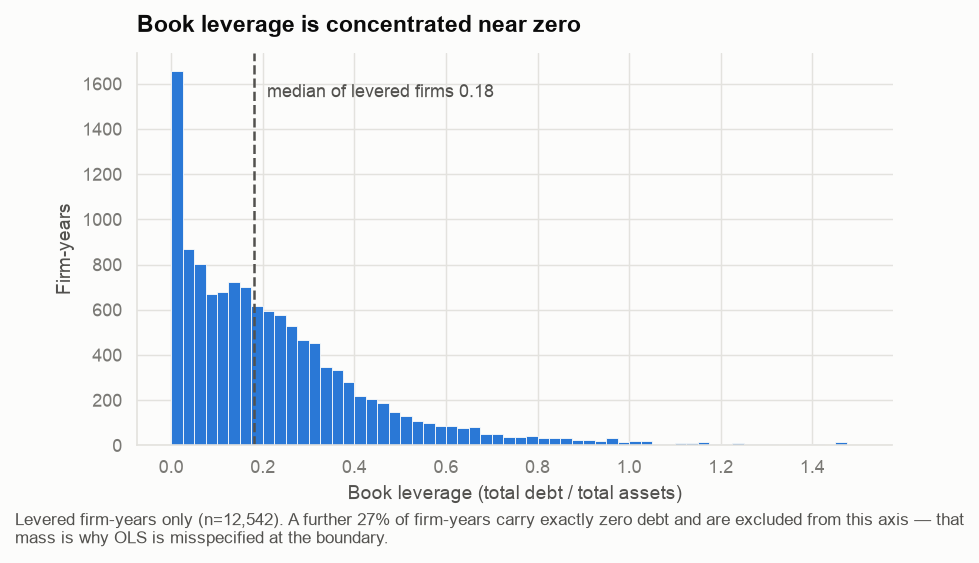

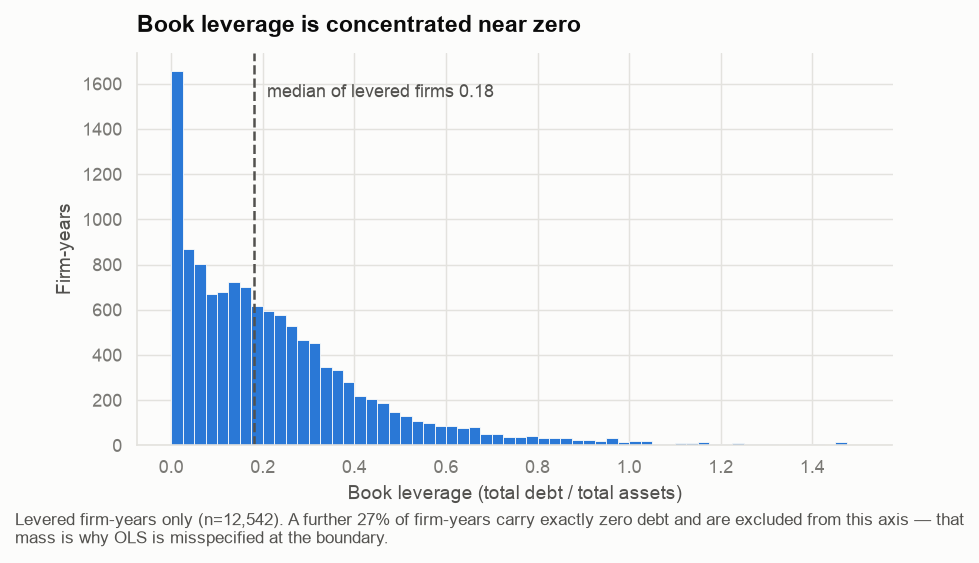

In [3]:
eda.fig_leverage_distribution(df)

## 3.3 Leverage by year

Three measures on different scales, so three panels rather than a second y-axis. The shaded
band is the out-of-sample test window (2020–2023).

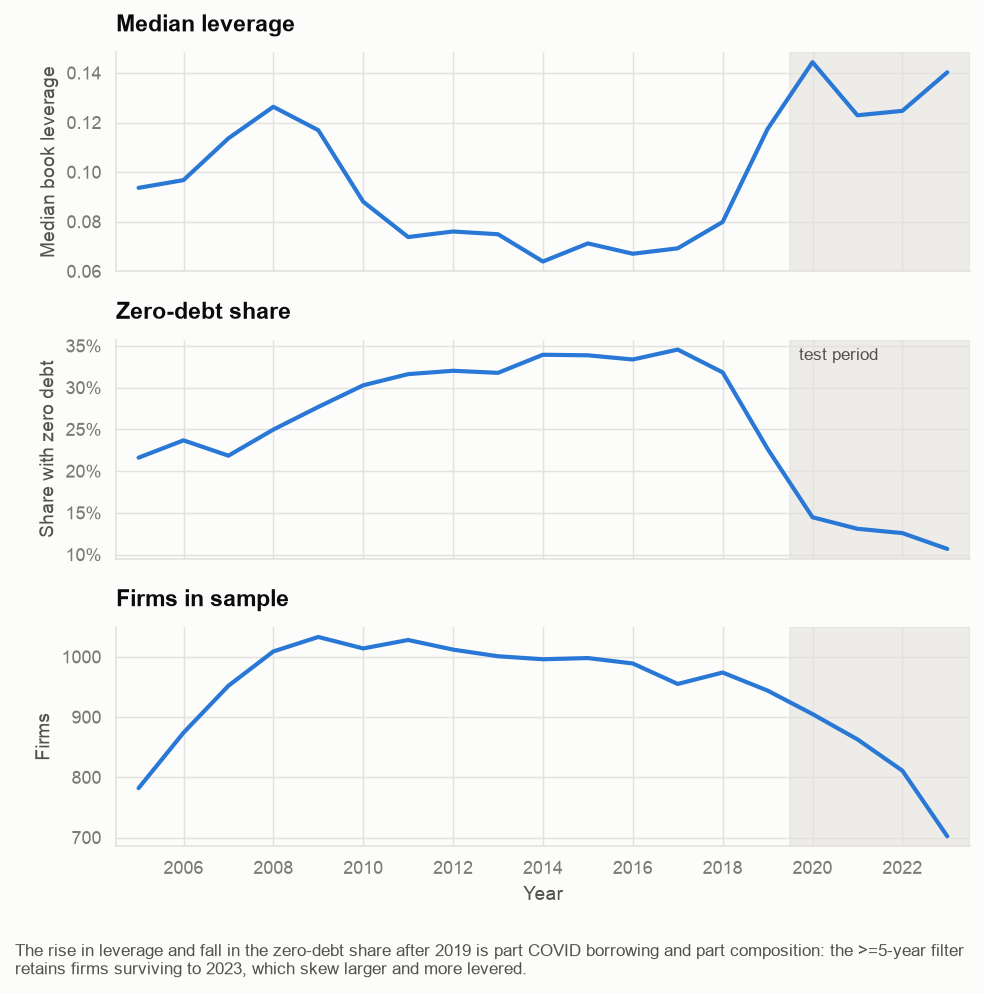

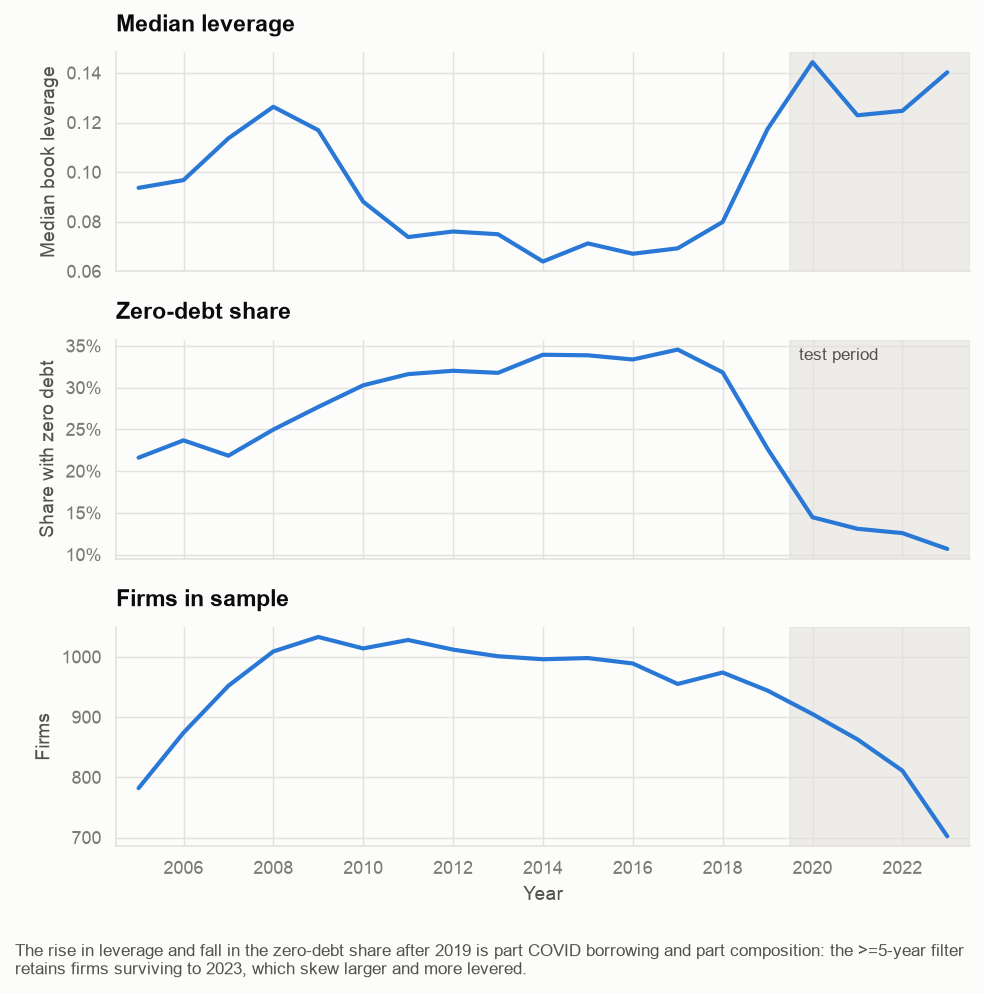

In [4]:
eda.fig_leverage_over_time(df)

## 3.2 Life cycle stages

Dickinson (2011): each firm-year is assigned from the signs of operating, investing and
financing cash flow. Eight sign combinations map to five stages.

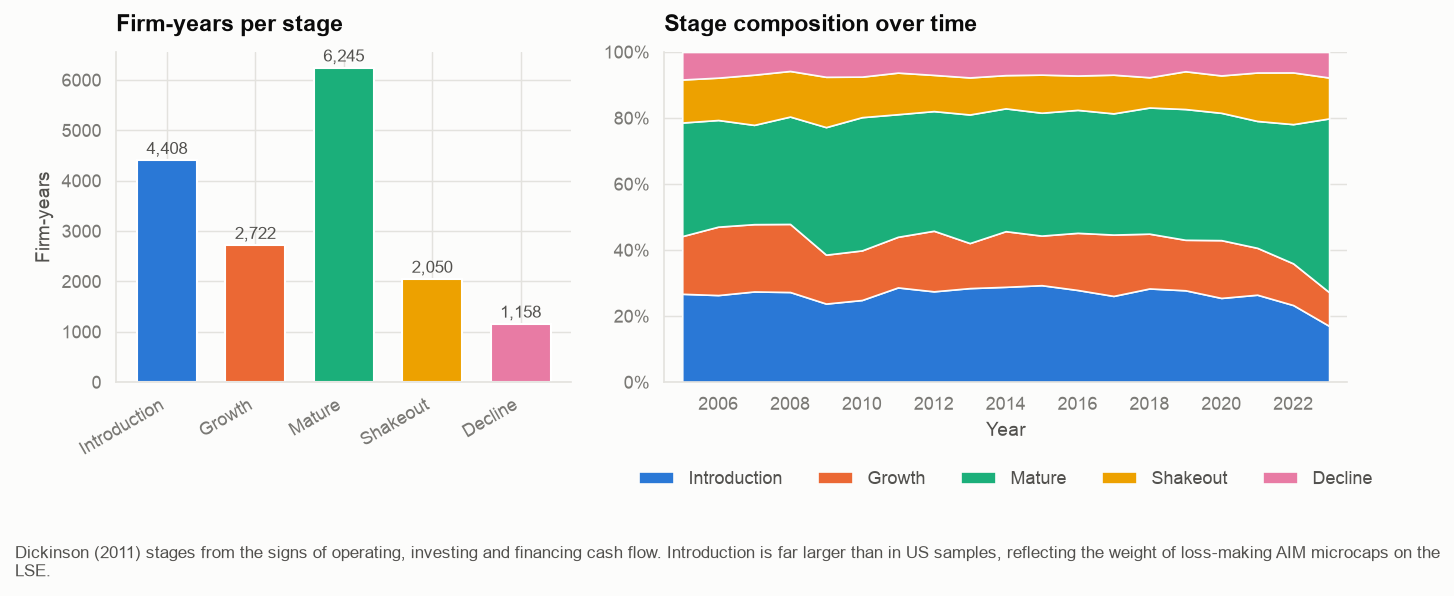

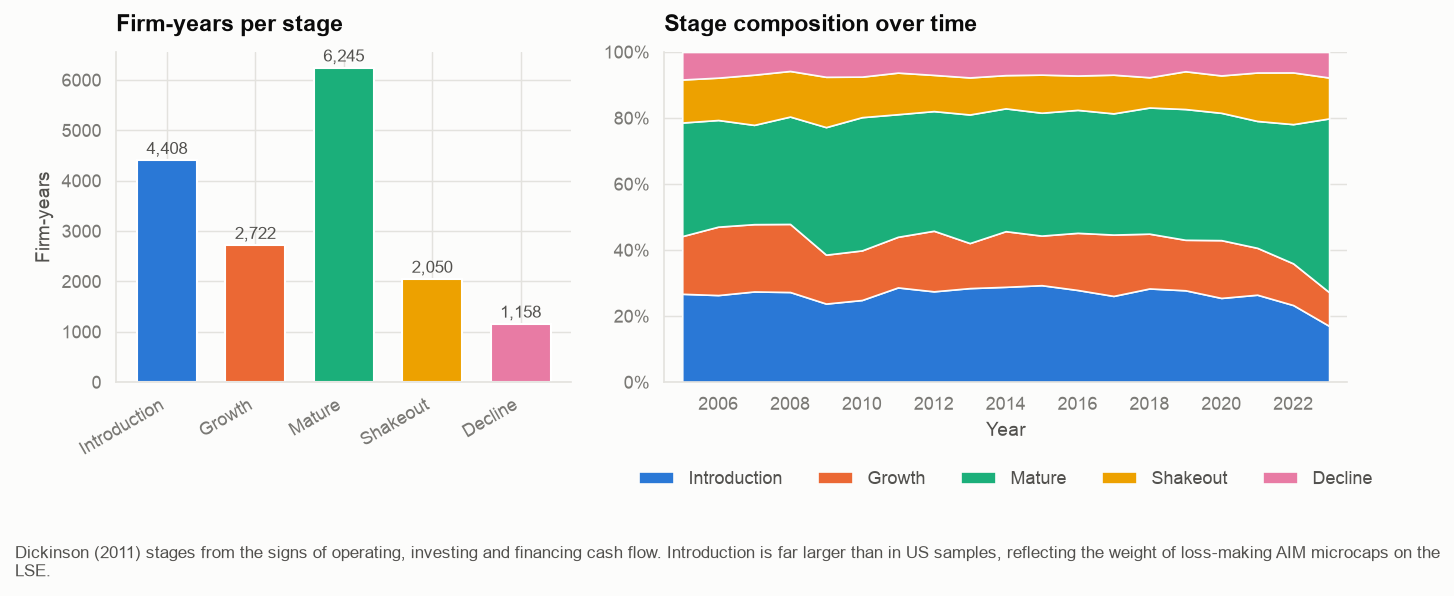

In [5]:
eda.fig_stage_distribution(df)

In [6]:
from src import lifecycle
lifecycle.stage_summary(df, split_year=C.TEST_START_YEAR)

,train_<2020,test_>=2020,n,share
lifecycle_stage,,,,
Mature,4891,1354,6245,37.7
Introduction,3661,747,4408,26.6
Growth,2280,442,2722,16.4
Shakeout,1619,431,2050,12.4
Decline,942,216,1158,7.0


### Leverage by stage

The ordering holds across two decades. A persistent gap is what justifies estimating
stage-specific models in Phase 5 rather than adding a stage dummy to one pooled model.

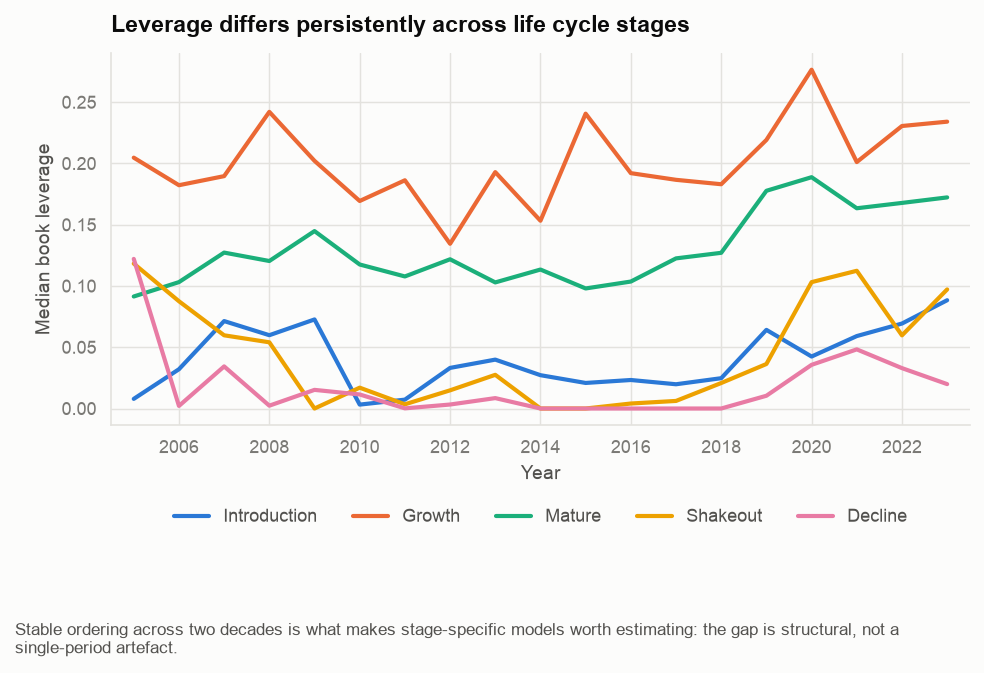

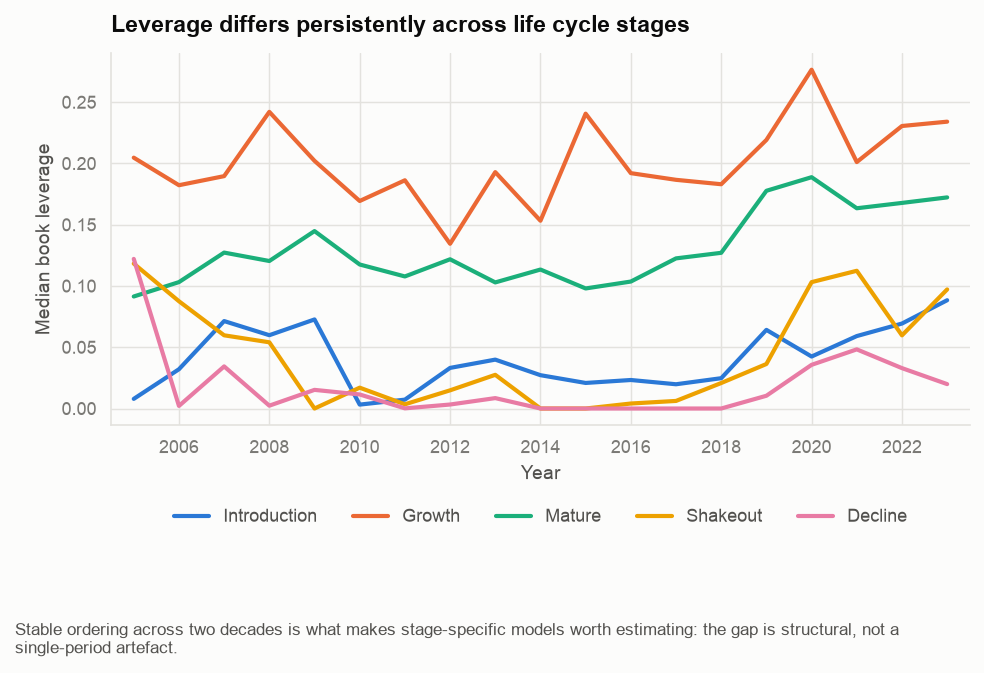

In [7]:
eda.fig_leverage_by_stage(df)

## 3.3 Leverage by sector

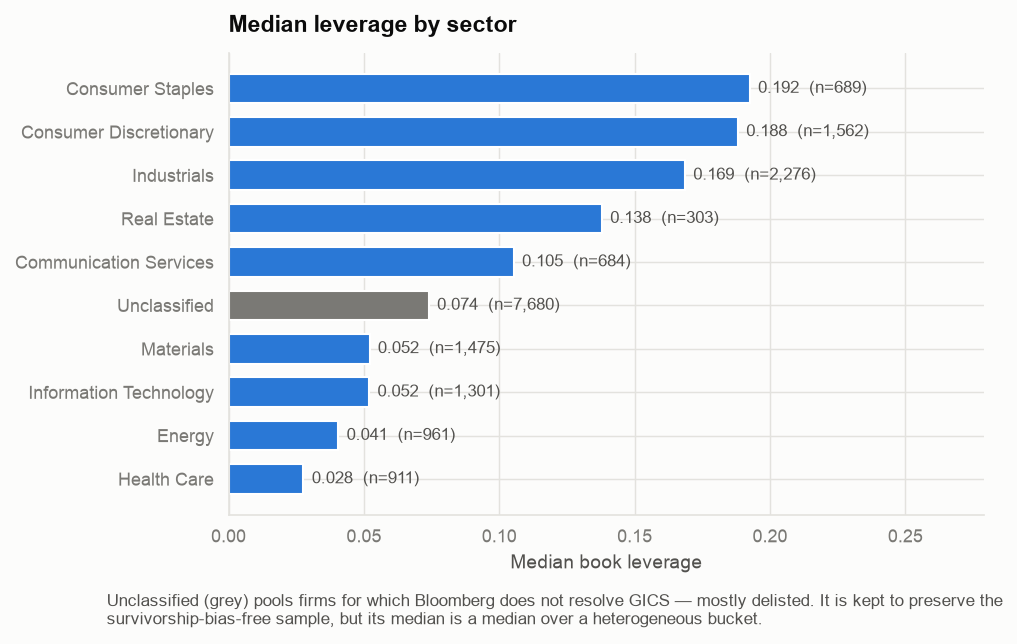

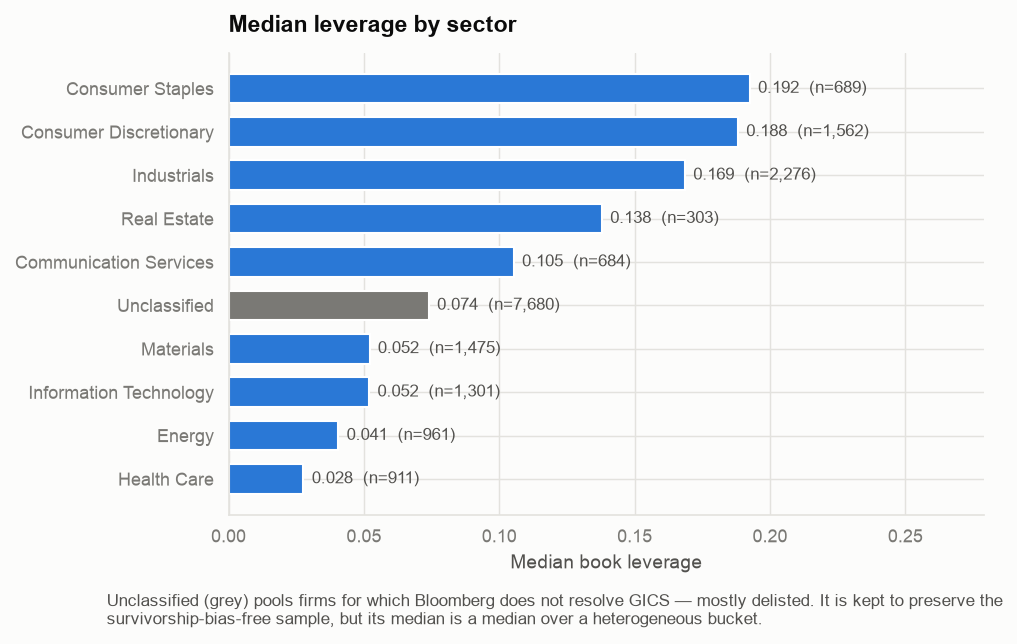

In [8]:
eda.fig_leverage_by_sector(df)

### The size–leverage relationship is non-linear

This is the empirical motivation for the whole modelling strategy. Median leverage rises
across every size decile and the zero-debt share falls monotonically, yet the Pearson
correlation is almost exactly zero. A linear model cannot see this; a tree model can.

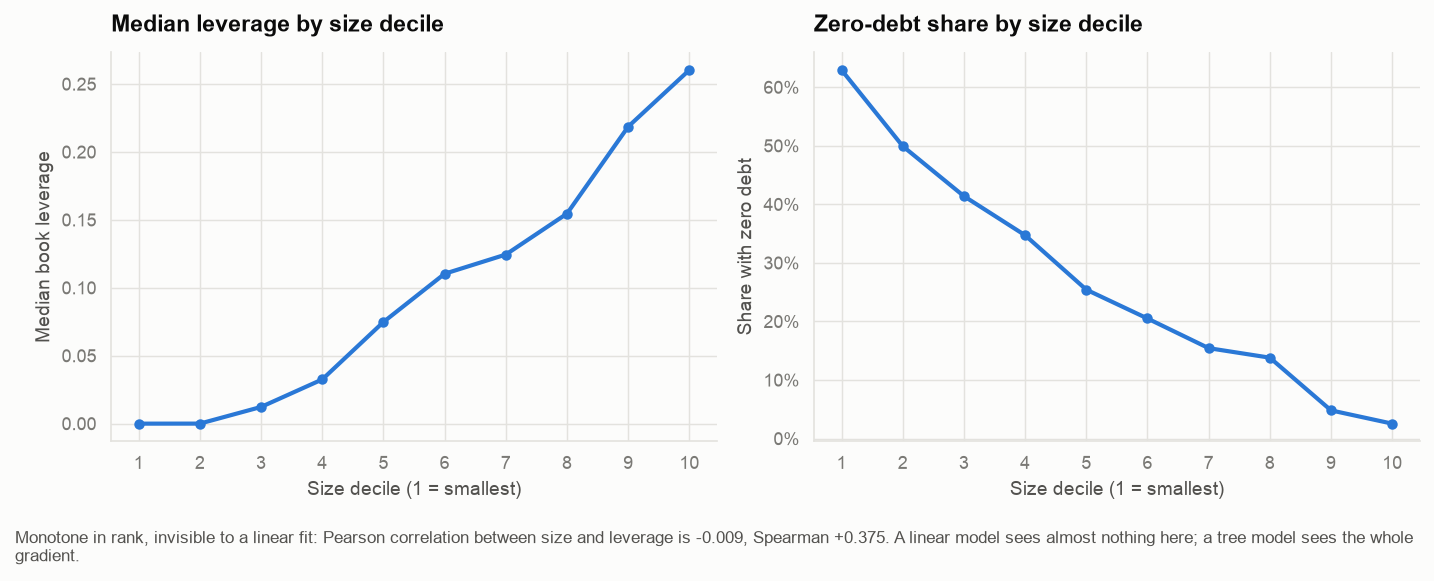

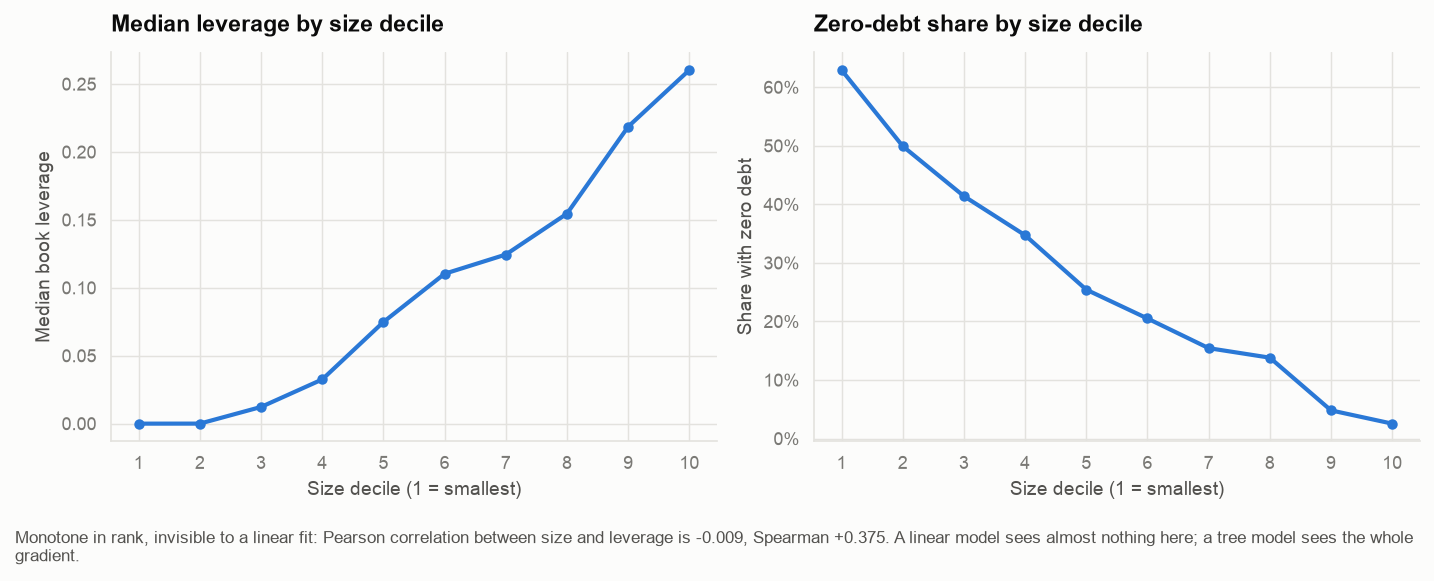

In [9]:
eda.fig_size_nonlinearity(df)

## 3.4 Correlation matrix

Pairs above |r| = 0.8 are collinear enough to matter for OLS and Lasso. Trees are unaffected.

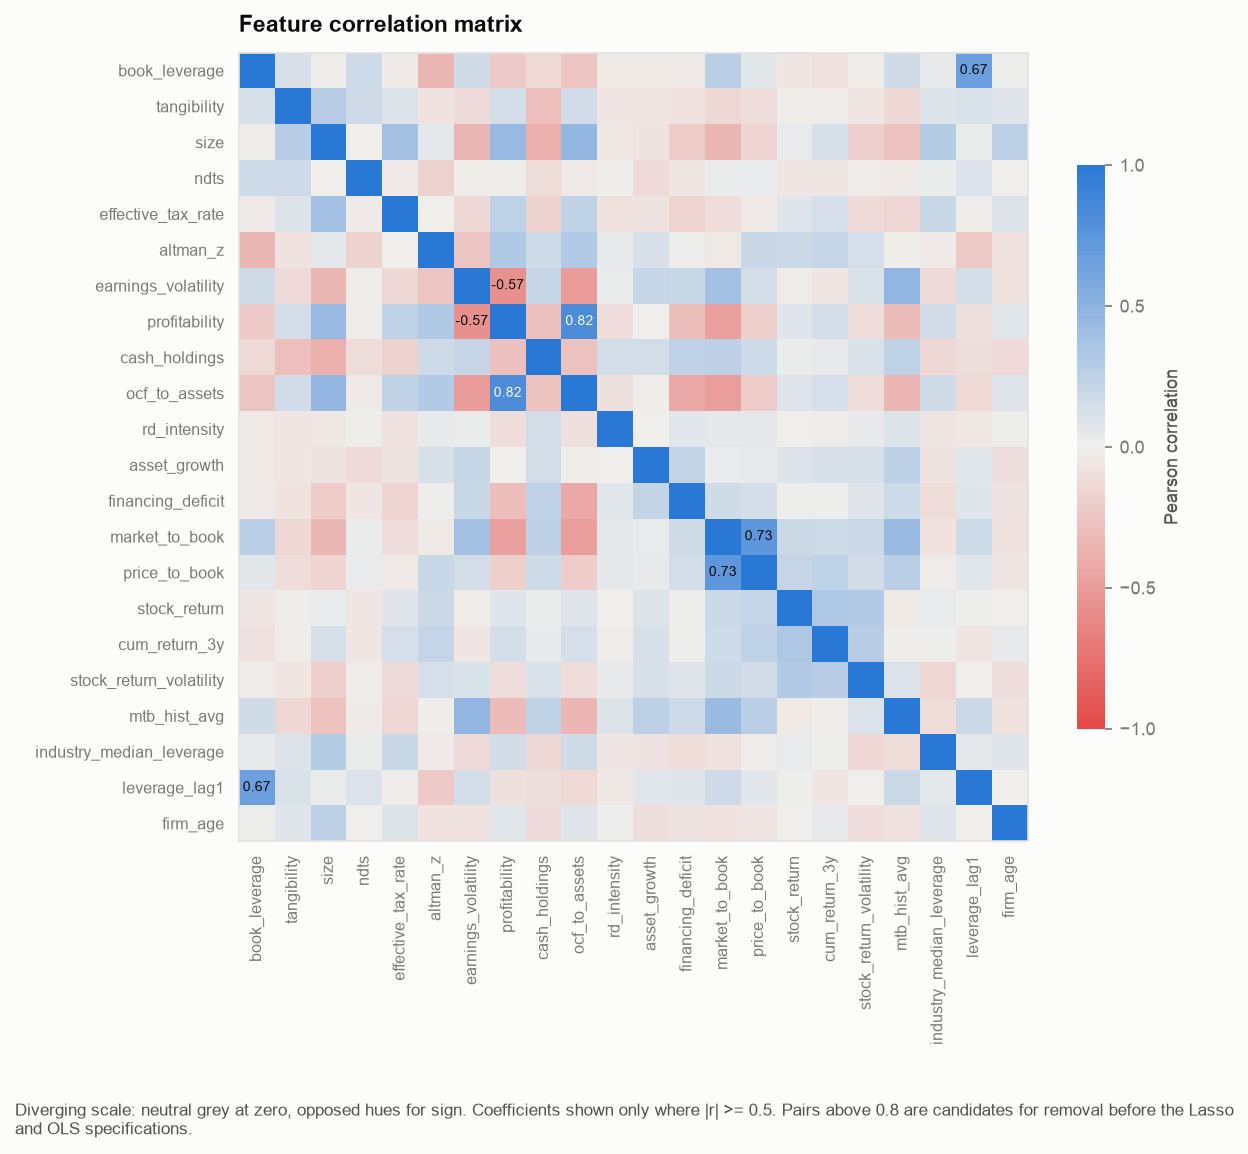

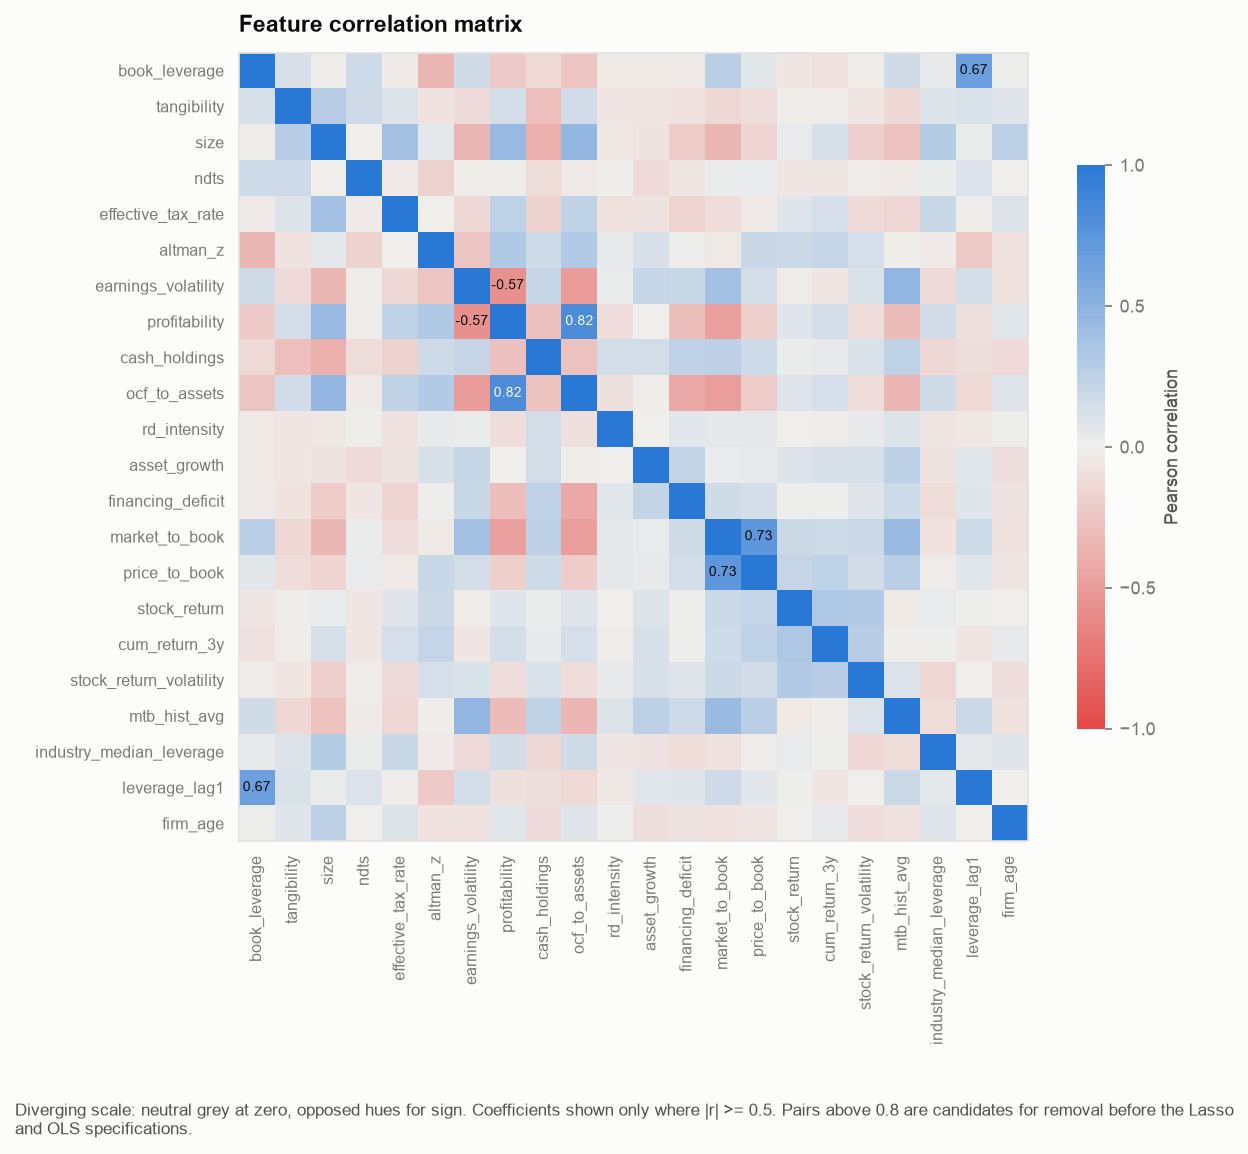

In [10]:
eda.fig_correlation(df, features)

In [11]:
pd.DataFrame(eda._high_correlations(df, features),
             columns=['feature_a', 'feature_b', 'r'])

,feature_a,feature_b,r
0,profitability,ocf_to_assets,0.824108


## 3.5 Missing data patterns

Rows dark on the left only are history-dependent by construction — lags and rolling windows
cannot exist in the first years of the panel. Those are not data failures and should not be
imputed away.

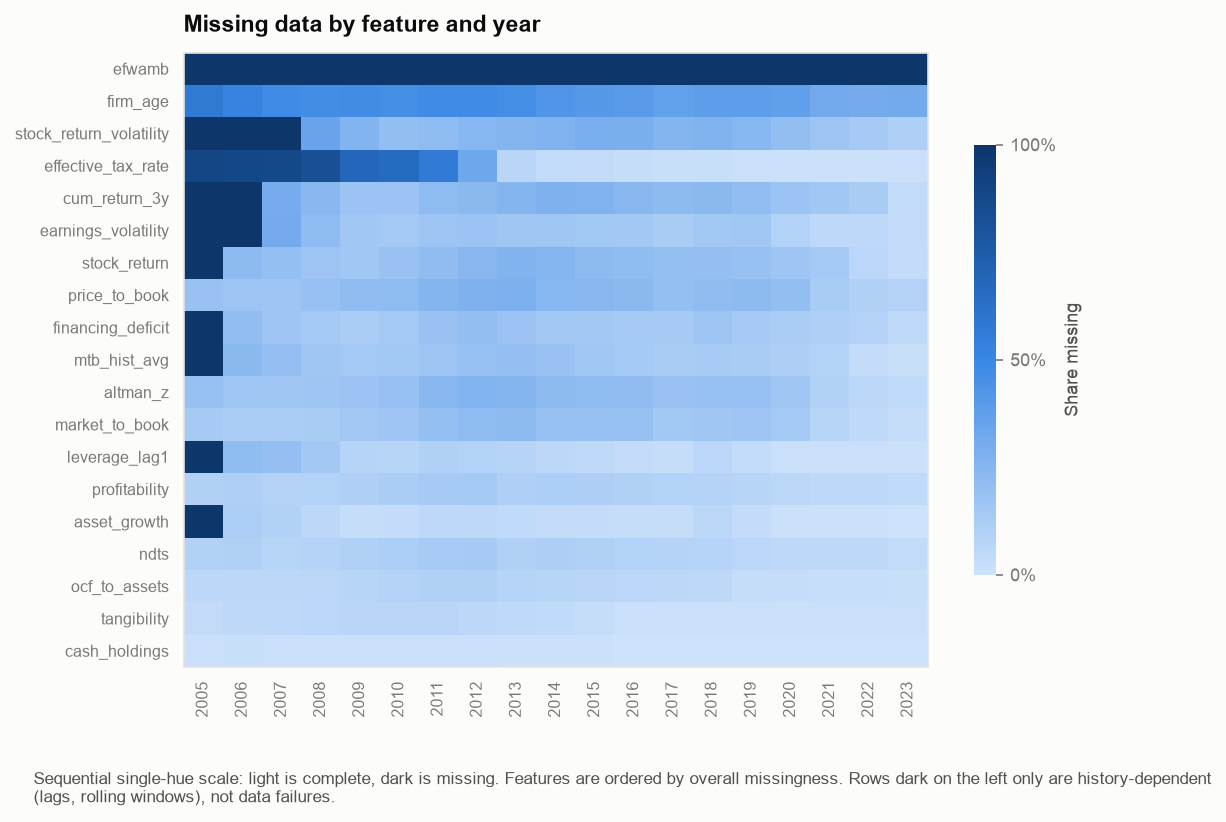

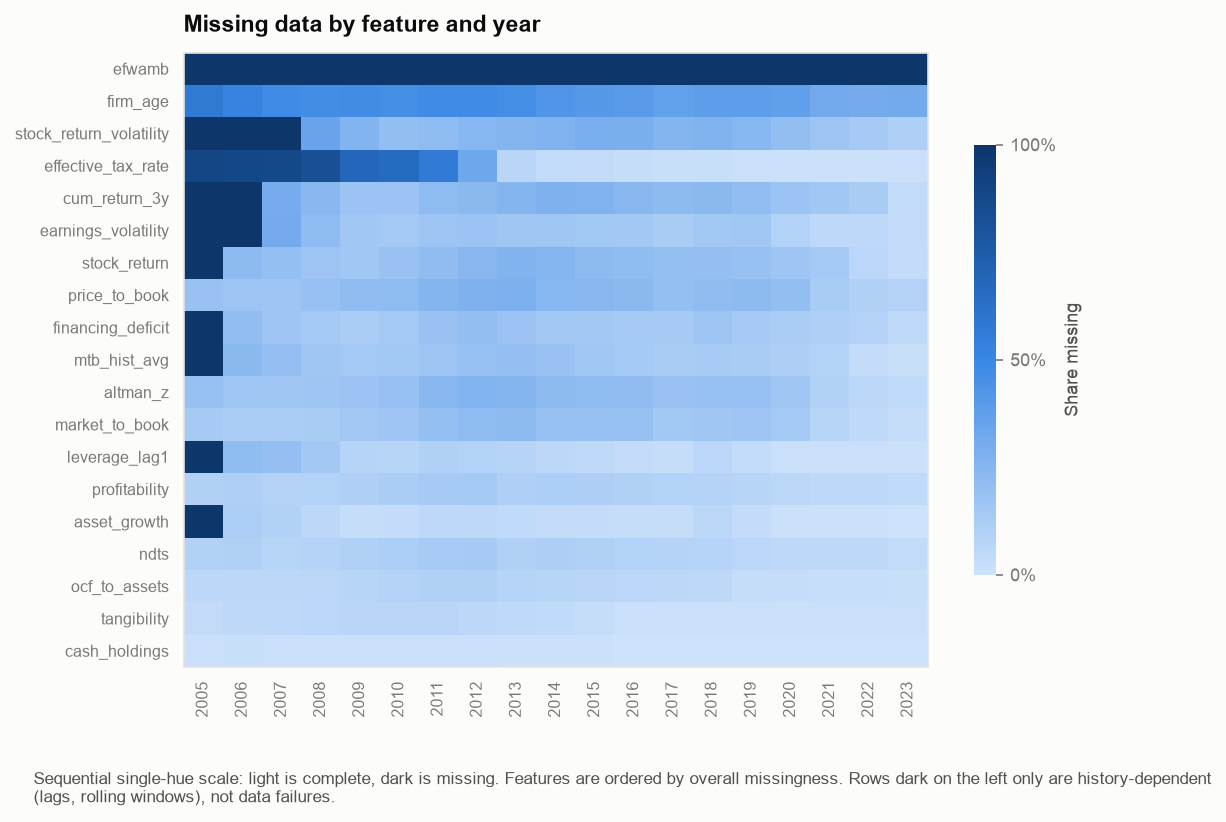

In [12]:
eda.fig_missingness(df, features)

## The 2019–20 structural break (IFRS 16)

Median leverage jumps and the zero-debt share collapses between 2018 and 2020. Three
checks show this is lease capitalisation under IFRS 16, not borrowing, growth or
survivorship — so it changes the *level* of the target, not the relationships.

In [ ]:
raw = pd.read_csv(C.OUTPUTS / 'panel_raw.csv')
eda.fig_ifrs16_break(df, raw)

### Stage persistence

Dickinson assigns a stage from one year's cash-flow signs, so stages are firm-year
states rather than firm attributes. Persistence sets how much weight the Phase 5
stage-specific results can carry.

In [ ]:
persistence, never, tm = eda.stage_persistence(df)
print(f'stays in same stage year-on-year: {persistence:.1%}')
print(f'firms that never change stage:    {never:.1%}')
tm.round(3)

---

Narrative summary with all figures and tables: `outputs/eda_report.md`.

**Next — Phase 4:** time-based split (train 2005–2019, test 2020–2023), OLS and Tobit
baselines, then Lasso, Random Forest and XGBoost.